# Títulos de películas similares

## Importando los datos

In [83]:
import pandas as pd

df_movies = pd.read_csv("/kaggle/input/movie-recommendation-system/movies.csv")
df_ratings = pd.read_csv("/kaggle/input/movie-recommendation-system/ratings.csv")

In [84]:
print(df_movies.head())
print(df_movies.info())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   genres   62423 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB
None


In [85]:
print(df_ratings.head())
print(df_ratings.info())

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 762.9 MB
None


## Extrayendo la proporcion de cada 

In [86]:
proportions = []
for value in df_ratings["rating"].unique():
    unique_rating = df_ratings.loc[df_ratings["rating"]==value]
    prop = len(unique_rating)/len(df_ratings)
    sample = unique_rating.sample(frac=prop)
    if len(sample) > 1000:
        proportions.append(sample)
    else:
        print(f"El puntaje: {value} contiene pocos valores")

df_ratings_filtered = pd.concat(proportions, axis=0)

### Uniendo el dataframe de puntajes (ratings) con el dataframe de películas (movies)

In [87]:
ratings_movies_merge = pd.merge(df_ratings_filtered, df_movies, on="movieId", how="inner")
ratings_movies_merge = ratings_movies_merge[["userId", "movieId", "title", "rating", "genres"]]
print(ratings_movies_merge.head())

   userId  movieId                               title  rating  \
0   12460     3608      Pee-wee's Big Adventure (1985)     5.0   
1   60335      357  Four Weddings and a Funeral (1994)     5.0   
2   60004     2997         Being John Malkovich (1999)     5.0   
3   93193     4308                 Moulin Rouge (2001)     5.0   
4   47338    55820       No Country for Old Men (2007)     5.0   

                  genres  
0       Adventure|Comedy  
1         Comedy|Romance  
2   Comedy|Drama|Fantasy  
3  Drama|Musical|Romance  
4            Crime|Drama  


## Estandarizando los títulos y géneros

In [88]:
import re

def clean_title(title: str) -> pd.Series:
    return re.sub("[^a-zA-Z0-9 ]", "", title)

In [89]:
ratings_movies_merge["title"] = ratings_movies_merge["title"].apply(lambda x: clean_title(x))
ratings_movies_merge["genres"] = ratings_movies_merge["genres"].str.split("|")

### Géneros únicos identificados

In [90]:
pd.Series([genero for lista_genero in ratings_movies_merge["genres"] for genero in lista_genero]).unique()

array(['Adventure', 'Comedy', 'Romance', 'Drama', 'Fantasy', 'Musical',
       'Crime', 'Mystery', 'Thriller', 'Action', 'Horror', 'Sci-Fi',
       'War', 'IMAX', 'Animation', 'Children', 'Film-Noir', 'Documentary',
       'Western', '(no genres listed)'], dtype=object)

## Excluyendo a las películas que no fueron asignados un género

In [91]:
genres_in = ratings_movies_merge[ratings_movies_merge["genres"].apply(lambda x: '(no genres listed)' not in x)]
pd.Series([genero for lista_genero in genres_in["genres"] for genero in lista_genero]).unique()

array(['Adventure', 'Comedy', 'Romance', 'Drama', 'Fantasy', 'Musical',
       'Crime', 'Mystery', 'Thriller', 'Action', 'Horror', 'Sci-Fi',
       'War', 'IMAX', 'Animation', 'Children', 'Film-Noir', 'Documentary',
       'Western'], dtype=object)

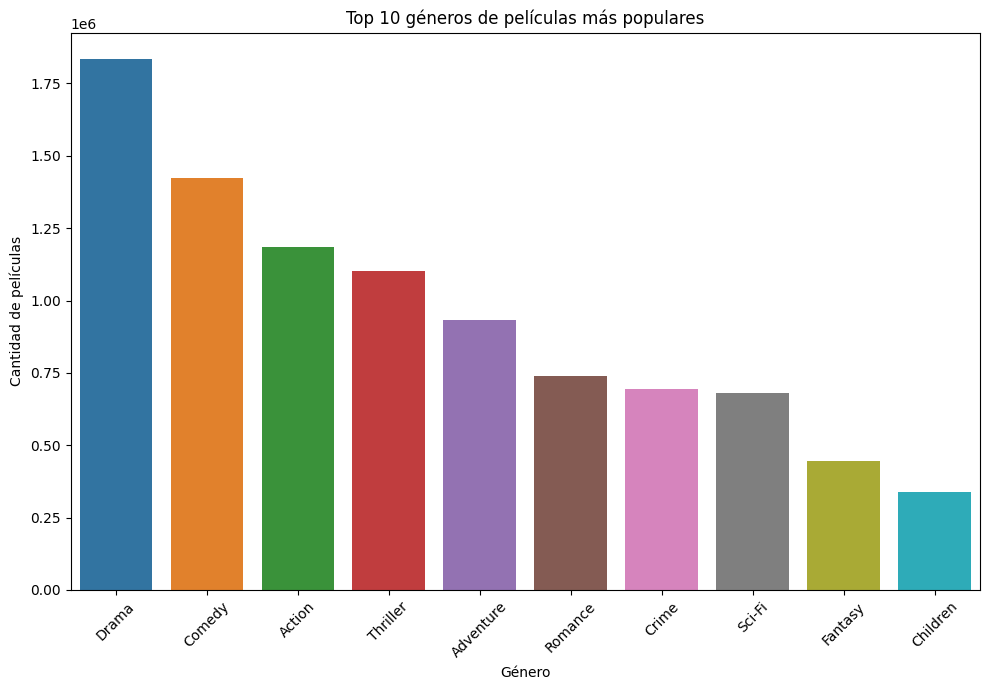

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

generos_peliculas = pd.Series([genero for lista_genero in genres_in["genres"] for genero in lista_genero])
top_generos = generos_peliculas.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_generos.index, y=top_generos.values, ax=ax)
plt.xticks(rotation=45)
plt.title("Top 10 géneros de películas más populares")
plt.xlabel("Género")
plt.ylabel("Cantidad de películas")
plt.tight_layout()
plt.show()

In [93]:
unique_genres = genres_in.explode("genres")

## Análisis de los datos

### Promedio de puntaje (rating) por película

In [94]:
print(genres_in.groupby("title")["rating"].mean().reset_index().sort_values(by="rating", ascending=False).head(10))

                                     title  rating
21057                         Perfume 2001     5.0
21658             Praxis Dr Hasenbein 1997     5.0
6597                   Crossing Point 2016     5.0
21809               Prinzessin Maleen 2015     5.0
21805             Princess of Thieves 2001     5.0
6625                            Cruel 2017     5.0
6635       Crulic  The Path to Beyond 2011     5.0
21711                     Pretty Bird 2008     5.0
21652                     Prairie Dog 2015     5.0
31660  Warning This Drug May Kill You 2017     5.0


### Top de audiencia por película

In [95]:
print(genres_in.groupby("title")["rating"].count().sort_values(ascending=False).head(10))

title
Forrest Gump 1994                        13715
Shawshank Redemption The 1994            13245
Pulp Fiction 1994                        13109
Silence of the Lambs The 1991            13066
Matrix The 1999                          11945
Jurassic Park 1993                       11450
Star Wars Episode IV  A New Hope 1977    11377
Terminator 2 Judgment Day 1991           10213
Toy Story 1995                           10146
Braveheart 1995                          10077
Name: rating, dtype: int64


### Top 3 de películas por género

In [96]:
print(unique_genres.groupby(["genres", "title"])["rating"].mean().reset_index()\
.sort_values(["genres", "rating"], ascending=[True, False])\
.groupby("genres").head(3).reset_index(drop=True))

         genres                                              title    rating
0        Action                            40 Days and Nights 2012  5.000000
1        Action                                    5th Street 2013  5.000000
2        Action                          A Place in the World 1992  5.000000
3     Adventure                            40 Days and Nights 2012  5.000000
4     Adventure                          All Men Are Brothers 1975  5.000000
5     Adventure                                Bachelor Games 2016  5.000000
6     Animation                                               1948  5.000000
7     Animation                 Adventures of Vasia Kurolesov 1981  5.000000
8     Animation                           Batman Strange Days 2014  5.000000
9      Children                              3 Days of Normal 2012  5.000000
10     Children    A Connecticut Yankee in King Arthurs Court 1949  5.000000
11     Children                 Adventures of Vasia Kurolesov 1981  5.000000

## Proceso de tokenización de títulos y filtrado de stopwords

In [97]:
df_movies["genres"] = df_movies["genres"].str.split("|")
df_movies_in = df_movies[df_movies["genres"].apply(lambda x: '(no genres listed)' not in x)]

In [98]:
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
import nltk
# nltk.download('punkt')
# nltk.download('stopwords')
titulos = df_movies_in["title"]
#tokenizar los titulos (aplicado individualmente a cada título)
tokens_titulos = titulos.apply(wordpunct_tokenize)
# obteniendo la lista de stopwords en ingles
stop_words = set(stopwords.words('english'))
# filtrando los stopwords de cada título tokenizado
filtered_titles = tokens_titulos.apply(
    lambda token_titulo: " ".join([word for word in token_titulo if word.lower() not in stop_words])
)
filtered_titles.head()

0               Toy Story ( 1995 )
1                 Jumanji ( 1995 )
2        Grumpier Old Men ( 1995 )
3          Waiting Exhale ( 1995 )
4    Father Bride Part II ( 1995 )
Name: title, dtype: object

## Vectorización de títulos y similitud coseno

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

vectorizer = TfidfVectorizer(ngram_range=(1, 2))
vectorizer_titles = vectorizer.fit_transform(filtered_titles)

def busqueda_titulo(titulo: str) -> pd.DataFrame:
    titulo = clean_title(titulo)
    query_title = vectorizer.transform([titulo])
    similitud = cosine_similarity(vectorizer_titles, query_title).flatten()
    indices = np.argpartition(similitud, -5)[-5:]
    resultados = df_movies_in.iloc[indices][::-1]
    return resultados

## Búsqueda de títulos similares

In [100]:
resultados_peliculas = busqueda_titulo("interstellar")
print(resultados_peliculas["title"].reset_index(drop=True))

0                   Interstellar (2014)
1    The Science of Interstellar (2014)
2                  Visitors, The (1972)
3           Excuse Me for Living (2012)
4              Sea of Grass, The (1947)
Name: title, dtype: object
